# STEP1. 핵심 산업·고용 상태 분석

> **Takeaway.** 생산과 고용의 상태·규모·시간 구조를 동일한 180행 패널에서 읽는다.

## 분석 질문

업종별 생산·고용 변화는 어떤 상태와 전환 패턴을 보이는가?

## 입력

| 구분 | 설정 변수 |
|---|---|
| 본분석 상태 패널 | `config.STATE_PANEL_PATH` |

## 출력

| 구분 | 설정 변수 |
|---|---|
| 핵심 표 | `config.CORE_TABLE_DIR` |
| 핵심 그림 | `config.CORE_FIGURE_DIR` |

## 전체 흐름

`공통 패널 로드 → 상태(Q1) → 규모(Q2) → 전환(Q3) → 핵심 관찰 정리`

## 0. 분석 개요

이 노트북은 검토가 끝난 Q1~Q3 분석을 **상태 → 규모 → 시간**의 한 흐름으로 통합한다. 새로운 분석 질문이나 판정 기준을 추가하지 않고, 저장소의 공통 분석 모듈과 `changwon_state_panel.csv`를 그대로 사용한다.

| 구분 | 질문 | 핵심 내용 |
|---|---|---|
| Q1 상태 | 같은 고용 변화라도 산업활동 상태는 다른가? | 명목 생산액 YoY와 고용 YoY 방향을 결합한 S1~S4 국면 |
| Q2 규모 | 고용 변화의 실제 규모는 얼마나 큰가? | 고용 증감 인원, 고용비중, 분기별 구성, 비례배분 기준선 |
| Q3 시간 | 국면은 일시적인가, 지속되는가, 어떻게 전환되는가? | 국면 경로, 지속기간, 인접 분기 전환 |

분석 단위는 창원국가산단의 업종×분기다. `production`은 명목 생산액(억원), `employment`는 고용 인원(명)이며 YoY는 전년동기 대비 변화율이다. 결과는 관측 자료가 직접 보여주는 범위에서만 해석한다.


## 1. 환경 설정 및 데이터 로딩

프로젝트 루트 또는 `notebooks` 디렉터리에서 실행할 수 있도록 입력 패널을 기준으로 저장소 루트를 찾는다. 사용자 PC의 절대경로는 사용하지 않는다.


In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / 'data/processed/kicox/changwon_state_panel.csv').is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('프로젝트의 data/processed/kicox/changwon_state_panel.csv가 필요합니다.')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from core.analysis import config, panel, plots, q1_state, q2_scale, q3_time

dirs = config.project_dirs(ROOT)
config.setup_matplotlib()
chained_assignment_warning = getattr(
    pd.errors, 'SettingWithCopyWarning', getattr(pd.errors, 'ChainedAssignmentError', Warning)
)
warnings.filterwarnings('error', category=chained_assignment_warning)

state, total = panel.load_panels(dirs['proc'])
ctx = panel.build_context(state)

print(f'프로젝트 루트 : {ROOT}')
print(f'분석기간      : {ctx.quarters[0]} ~ {ctx.latest} ({len(ctx.quarters)}분기)')
print(f'분석대상      : {len(ctx.industries)}개 업종 × {len(ctx.quarters)}분기 = {len(state)}행')
print(f'최신분기      : {ctx.latest}; YoY 기준분기: {ctx.base_q}')
print(f'중립구간      : threshold={ctx.threshold}')
print(f'주요 변수     : 명목 생산액(억원), 고용(명), 생산·고용 YoY(%), 국면, run, transition')


프로젝트 루트 : C:\Users\jiwoo\Desktop\GitHub\Changwon-Industry-Employment-Monitor
분석기간      : 2022Q1 ~ 2026Q2 (18분기)
분석대상      : 10개 업종 × 18분기 = 180행
최신분기      : 2026Q2; YoY 기준분기: 2025Q2
중립구간      : threshold=0
주요 변수     : 명목 생산액(억원), 고용(명), 생산·고용 YoY(%), 국면, run, transition


## 2. 공통 데이터 준비

전처리를 다시 수행하지 않는다. 전처리 파이프라인이 만든 본분석 패널을 읽고, Q2 표현에 필요한 전년동기 고용 수준과 증감 인원만 기존 정의대로 붙인다. Q1~Q3는 모두 같은 `state` 객체를 사용한다.

- S1: 명목 생산액↑·고용↑
- S2: 명목 생산액↑·고용↓
- S3: 명목 생산액↓·고용↑
- S4: 명목 생산액↓·고용↓
- N: 유효한 YoY 중 한 지표 이상이 정확히 0%
- INVALID: 필요한 값이 없어 계산 불가


In [2]:
state = panel.add_display_columns(state)
mfg = panel.manufacturing_totals(state, ctx)
verification_message = panel.verify_panel(state, ctx)
state_count = panel.state_counts(state)
missing = panel.missing_summary(state)
additivity, lag_mfg, additivity_result = panel.additivity_check(state, total, mfg, ctx)

print(verification_message)
display(state_count)
display(missing)
print(f'생산 합계 최대 절대차: {additivity_result["production_max_abs_gap"]:.6f}억원')
print(f'{ctx.latest} 업종 합계와 산단 고용 총계 차이: '
      f'{additivity_result["employment_gap_latest"]:+,.0f}명')
print('Q2는 범위가 일치하는 10개 업종 합계 안에서 고용 변화를 분해한다.')


검산: 달력 분기, YoY, 국면, 연속기간, 인접 전환 일치


,관측 수
state,
S1,54
S2,43
S3,13
S4,46
N,4
INVALID,20


,관측수,당분기생산결측,전년동기생산결측
quarter,,,
2023Q4,10,10,0
2024Q4,10,0,10


생산 합계 최대 절대차: 0.000050억원
2026Q2 업종 합계와 산단 고용 총계 차이: -4,851명
Q2는 범위가 일치하는 10개 업종 합계 안에서 고용 변화를 분해한다.


## 3. Q1 — 산업·고용 상태 분석

생산·고용 YoY의 부호를 결합한 기존 S1~S4 판정과 threshold=0 기준을 유지한다. 명목 생산액의 증가는 실제 물량 증가나 원인을 뜻하지 않는다.

## 3.1 최신분기 국면과 생산·고용 변화


,생산 YoY(%),고용 YoY(%),고용(명),국면
industry,,,,
기계,-19.55,-6.34,58784.0,S4
전기전자,2.70,-0.41,27979.0,S2
운송장비,19.64,-0.78,16308.0,S2
철강,32.65,-1.14,9689.0,S2
음식료,0.87,-3.79,635.0,S2
석유화학,-6.73,9.56,619.0,S3
목재종이,-12.90,-10.08,428.0,S4
비금속,45.67,-1.08,183.0,S2
기타,3.03,17.12,171.0,S1


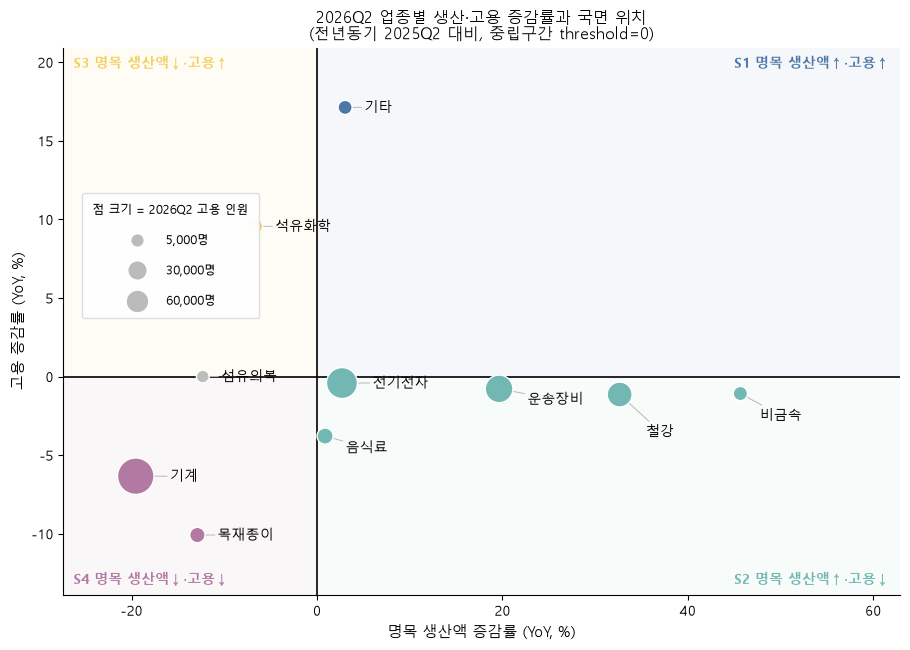

2026Q2 고용 감소 업종 7개 중 명목 생산액 증가 업종은 5개(전기전자, 운송장비, 철강, 음식료, 비금속)다.
해당 업종의 고용비중 합계는 47.7%다.


In [3]:
q1_latest = q1_state.latest_quadrant(state, ctx)
q1_all, q1_emp_down, q1_prod_up, q1_latest_result = q1_state.latest_state_summary(state, ctx)

display(q1_latest[['production_yoy', 'employment_yoy', 'employment', 'state']]
        .rename(columns={'production_yoy': '생산 YoY(%)', 'employment_yoy': '고용 YoY(%)',
                         'employment': '고용(명)', 'state': '국면'}).round(2))
fig = plots.plot_q1_quadrant(q1_latest, ctx, dirs['fig'])
display(fig)
plt.close(fig)

print(f'{ctx.latest} 고용 감소 업종 {q1_latest_result["n_down"]}개 중 명목 생산액 증가 업종은 '
      f'{q1_latest_result["n_nominal_up"]}개('
      f'{", ".join(q1_latest_result["nominal_up_industries"])})다.')
print(f'해당 업종의 고용비중 합계는 {q1_latest_result["nominal_employment_share_pct"]:.1f}%다.')


## 3.2 업종×분기 국면 분포

INVALID는 구성비 계산에서 제외한다. 결측 구간은 지속기간에서 연결하지 않는다.


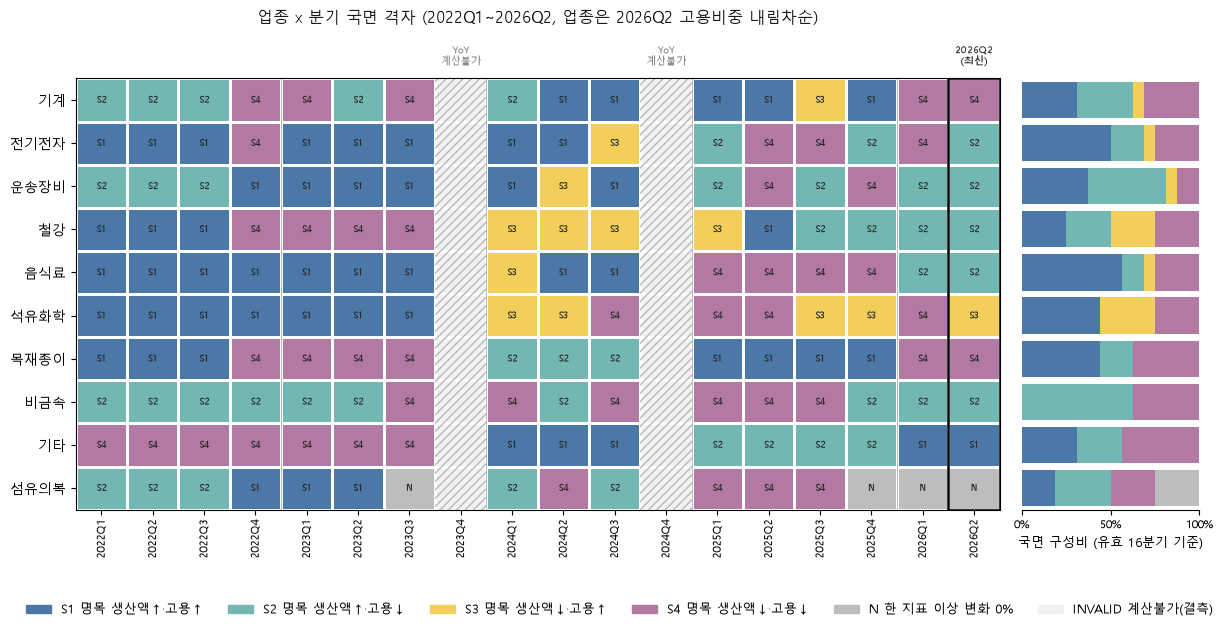

전체 관측기간 고용 감소 89건 중 명목 생산액 증가 43건(48.3%)
업종×분기 고용 인원 가중 비율: 53.0%
관측 건수 비율과 고용 인원 가중 비율은 의미가 다르며, 반복 관측을 독립 표본으로 보지 않는다.


In [4]:
state_pivot, state_comp = q1_state.state_grid(state, ctx)
fig = plots.plot_state_grid(state_pivot, state_comp, ctx, dirs['fig'])
display(fig)
plt.close(fig)

emp_down_history, emp_down_top4, q1_history_result = q1_state.history_stats(state, ctx)
print(f'전체 관측기간 고용 감소 {q1_history_result["n_down"]}건 중 명목 생산액 증가 '
      f'{q1_history_result["n_up_down"]}건({q1_history_result["simple_pct"]:.1f}%)')
print(f'업종×분기 고용 인원 가중 비율: {q1_history_result["weighted_pct"]:.1f}%')
print('관측 건수 비율과 고용 인원 가중 비율은 의미가 다르며, 반복 관측을 독립 표본으로 보지 않는다.')


## 3.3 국면 경계 민감도

±0.5/1/2% 민감도는 본분석 threshold=0을 대체하지 않고, 경계 부근 관측이 얼마나 민감한지만 보여준다.


In [5]:
q1_sensitivity = q1_state.threshold_sensitivity(state)
display(q1_sensitivity)
print('동일 패널에서 중립구간만 변경한 보조 집계이며 본분석 국면은 바꾸지 않았다.')


,S1,S2,S3,S4,N,INVALID
threshold,,,,,,
0.5,51,41,11,46,11,20
1.0,50,33,11,43,23,20
2.0,41,29,7,36,47,20


동일 패널에서 중립구간만 변경한 보조 집계이며 본분석 국면은 바꾸지 않았다.


## 4. Q2 — 고용 변화 규모 분석

Q1의 동일한 상태 패널에서 전년동기 대비 고용 증감 인원과 고용비중을 계산한다. 기여율은 순변화/총변화 비율이 저장소의 표시 기준 이상일 때만 제시한다.

## 4.1 최신분기 고용 증감 인원과 비중


,고용,고용_전년,증감인원,증감률%,고용비중%,국면,기여율%,비례기대증감,초과증감
industry,,,,,,,,,
기계,58784.0,62763.0,-3979.0,-6.34,51.19,S4,91.85,-2281.68,-1697.32
운송장비,16308.0,16437.0,-129.0,-0.78,14.20,S2,2.98,-597.55,468.55
전기전자,27979.0,28095.0,-116.0,-0.41,24.37,S2,2.68,-1021.36,905.36
철강,9689.0,9801.0,-112.0,-1.14,8.44,S2,2.59,-356.30,244.30
목재종이,428.0,476.0,-48.0,-10.08,0.37,S4,1.11,-17.30,-30.70
음식료,635.0,660.0,-25.0,-3.79,0.55,S2,0.58,-23.99,-1.01
비금속,183.0,185.0,-2.0,-1.08,0.16,S2,0.05,-6.73,4.73
섬유의복,34.0,34.0,0.0,0.00,0.03,N,-0.00,-1.24,1.24
기타,171.0,146.0,25.0,17.12,0.15,S1,-0.58,-5.31,30.31


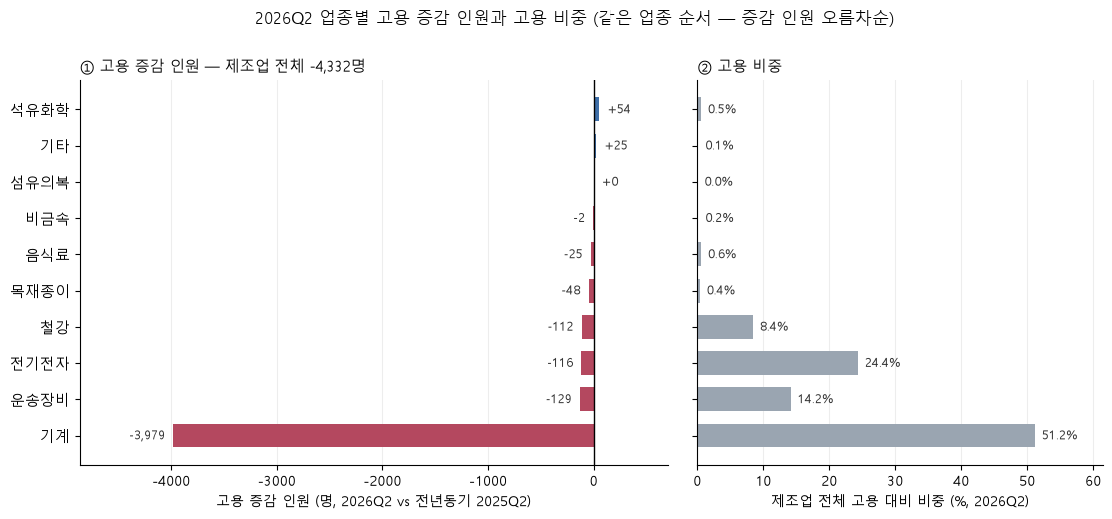

2026Q2 제조업 고용 114,830명, 전년동기 대비 -4,332명(-3.6%)
순변화/총변화 비율 0.965; 기여율 표시 가능


In [6]:
q2, net_delta, net_gross_ratio, contrib_usable = q2_scale.latest_scale(state, mfg, ctx)
q2 = q2_scale.baseline_comparison(q2)
q2_summary, main_industries, recent_quarters = q2_scale.scale_summary(state, q2, ctx)
q2_result = q2_scale.q2_results(
    q2, q2_summary, main_industries, net_delta, net_gross_ratio, contrib_usable, ctx
)

display(q2.round(2))
fig = plots.plot_q2_scale(q2, net_delta, ctx, dirs['fig'])
display(fig)
plt.close(fig)

print(f'{ctx.latest} 제조업 고용 {q2_result["employment"]:,.0f}명, 전년동기 대비 '
      f'{q2_result["net_delta"]:+,.0f}명({q2_result["net_yoy_pct"]:+.1f}%)')
print(f'순변화/총변화 비율 {q2_result["ratio"]:.3f}; '
      f'기여율 표시 {"가능" if q2_result["contrib_usable"] else "불가"}')


## 4.2 분기별 고용 변화 구성과 주요 업종 선별

주요 업종은 기존 표시 기준인 최신분기 고용비중 5% 이상이면서 최근 4분기 YoY 증감 절대합 300명 이상인 업종이다. 이는 정책 우선순위나 통계적 유의성 기준이 아니다.


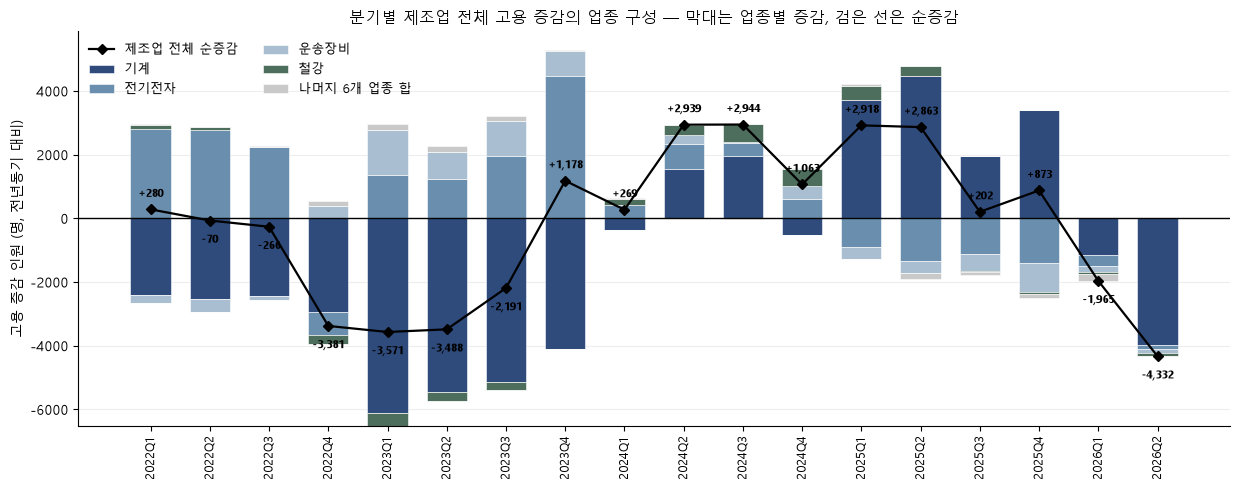

,고용비중%,2026Q2_증감인원,2026Q2_증감률%,2026Q2_국면,최근4분기_평균고용_전년대비증감,최근4분기_YoY증감절대합,최근4분기_기간순증감,상세표시대상,비례기대증감,초과증감
industry,,,,,,,,,,
기계,51.19,-3979.0,-6.34,S4,59.50,10478.0,-3979.0,True,-2281.68,-1697.32
전기전자,24.37,-116.0,-0.41,S2,-752.25,3009.0,-116.0,True,-1021.36,905.36
운송장비,14.20,-129.0,-0.78,S2,-429.25,1717.0,-129.0,True,-597.55,468.55
철강,8.44,-112.0,-1.14,S2,-77.25,309.0,-112.0,True,-356.30,244.30
음식료,0.55,-25.0,-3.79,S2,-193.00,772.0,-25.0,False,-23.99,-1.01
석유화학,0.54,54.0,9.56,S3,23.75,105.0,54.0,False,-20.54,74.54
목재종이,0.37,-48.0,-10.08,S4,104.50,616.0,-48.0,False,-17.30,-30.70
비금속,0.16,-2.0,-1.08,S2,-32.00,128.0,-2.0,False,-6.73,4.73
기타,0.15,25.0,17.12,S1,-8.50,128.0,25.0,False,-5.31,30.31


상세 경로 표시 업종: 기계, 전기전자, 운송장비, 철강
이들 업종의 최신분기 고용비중 합계: 98.2%
YoY 증감절대합은 같은 인원이 여러 분기에 반복 반영될 수 있어 신규·소멸 일자리 수가 아니다.


In [7]:
composition, composition_quarters, main_candidates, rest_industries = q2_scale.quarterly_composition(state, ctx)
fig = plots.plot_q2_composition(composition, composition_quarters, dirs['fig'])
display(fig)
plt.close(fig)

display(q2_summary.round(2))
print(f'상세 경로 표시 업종: {", ".join(main_industries) if main_industries else "없음"}')
print(f'이들 업종의 최신분기 고용비중 합계: {q2_result["main_share_pct"]:.1f}%')
print('YoY 증감절대합은 같은 인원이 여러 분기에 반복 반영될 수 있어 신규·소멸 일자리 수가 아니다.')


## 4.3 규모를 통제한 비례배분 기준선

비례기대증감은 제조업 전체 순증감을 전년동기 고용비중대로 나눈 비교값이다. 초과증감은 실제 증감에서 이 기준선을 뺀 값이며 원인을 뜻하지 않는다.


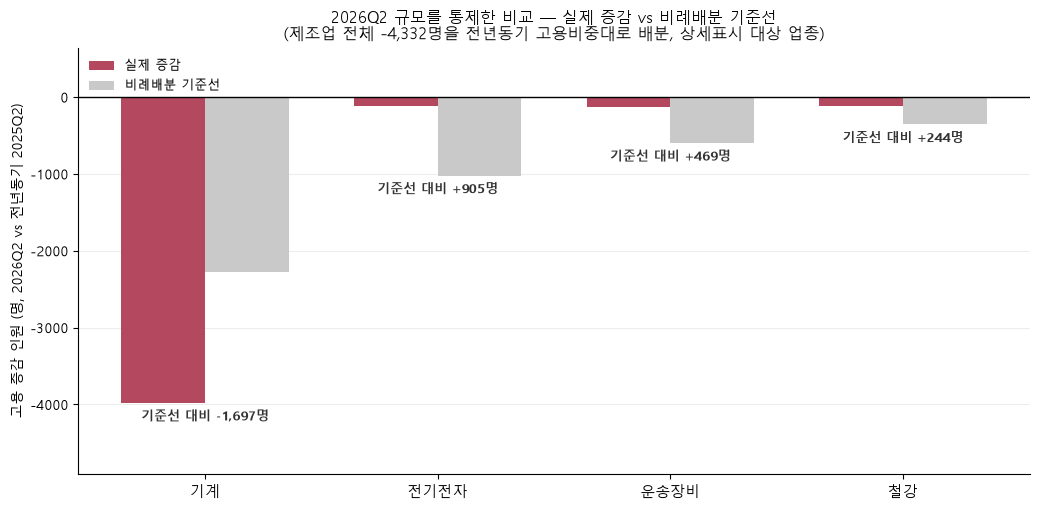

,증감인원,비례기대증감,초과증감,고용비중%
industry,,,,
기계,-3979.0,-2281.7,-1697.3,51.2
전기전자,-116.0,-1021.4,905.4,24.4
운송장비,-129.0,-597.5,468.5,14.2
철강,-112.0,-356.3,244.3,8.4
음식료,-25.0,-24.0,-1.0,0.6
석유화학,54.0,-20.5,74.5,0.5
목재종이,-48.0,-17.3,-30.7,0.4
비금속,-2.0,-6.7,4.7,0.2
기타,25.0,-5.3,30.3,0.1


기준선 대비 감소 폭이 가장 큰 업종은 기계(-1,697명)이다.


In [8]:
fig = plots.plot_q2_baseline(q2, main_industries, net_delta, ctx, dirs['fig'])
display(fig)
plt.close(fig)
display(q2.loc[ctx.ind_order_emp, ['증감인원', '비례기대증감', '초과증감', '고용비중%']].round(1))
print(f'기준선 대비 감소 폭이 가장 큰 업종은 '
      f'{q2_result["baseline_max_excess_decrease_industry"]}('
      f'{q2_result["baseline_max_excess_decrease"]:+,.0f}명)이다.')


## 5. Q3 — 국면 지속·전환 분석

Q1의 상태 판정 결과를 그대로 재사용한다. 지속기간은 S1~S4만 집계하고, 인접 전환표에는 N을 포함한다. INVALID를 가로질러 연결하지 않는다.

## 5.1 주요 업종의 시간 흐름


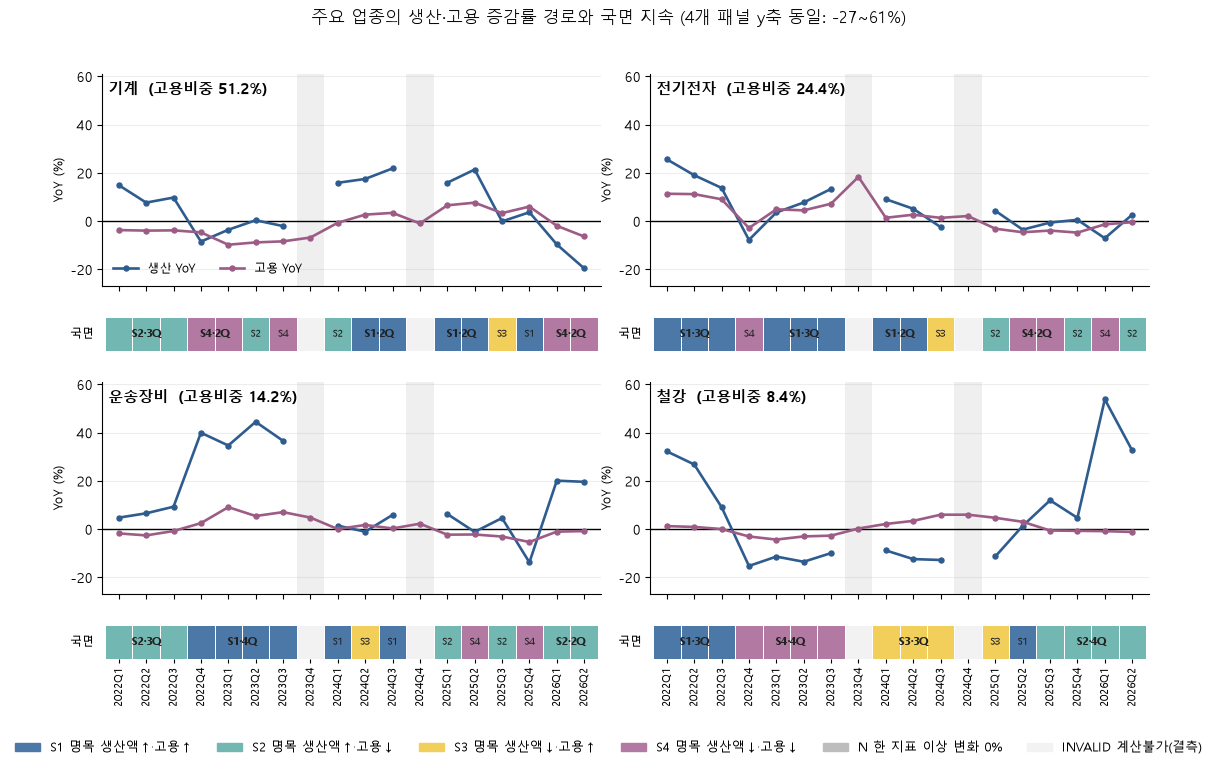

모든 패널의 y축 범위는 같고, 국면 리본은 Q1의 명목 생산액 기준 국면이다.


In [9]:
fig = plots.plot_q3_paths(state, ctx, main_industries, dirs['fig'])
display(fig)
plt.close(fig)
print('모든 패널의 y축 범위는 같고, 국면 리본은 Q1의 명목 생산액 기준 국면이다.')


## 5.2 현재 및 최장 관측 지속기간

패널 시작·끝 또는 결측에 닿은 run은 실제 지속기간이 더 길 수 있다. 최신 국면은 아직 끝나지 않은 우측 절단 관측일 수 있다.


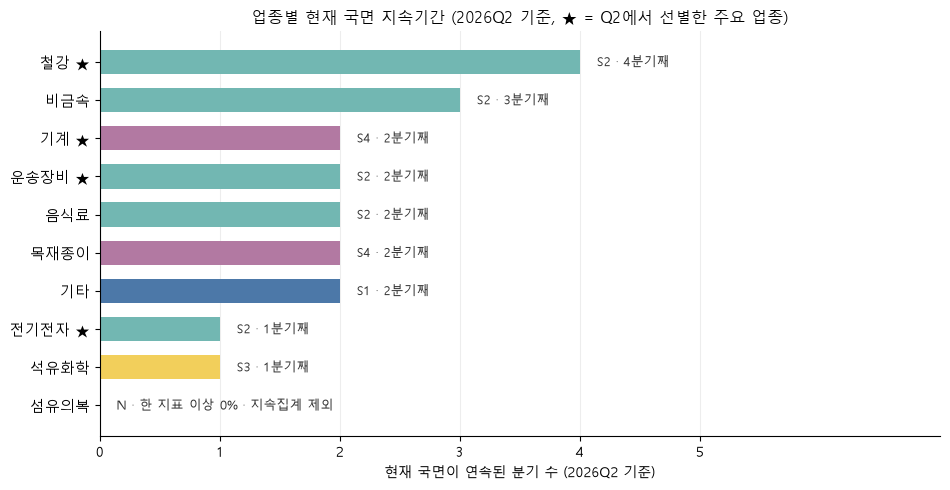

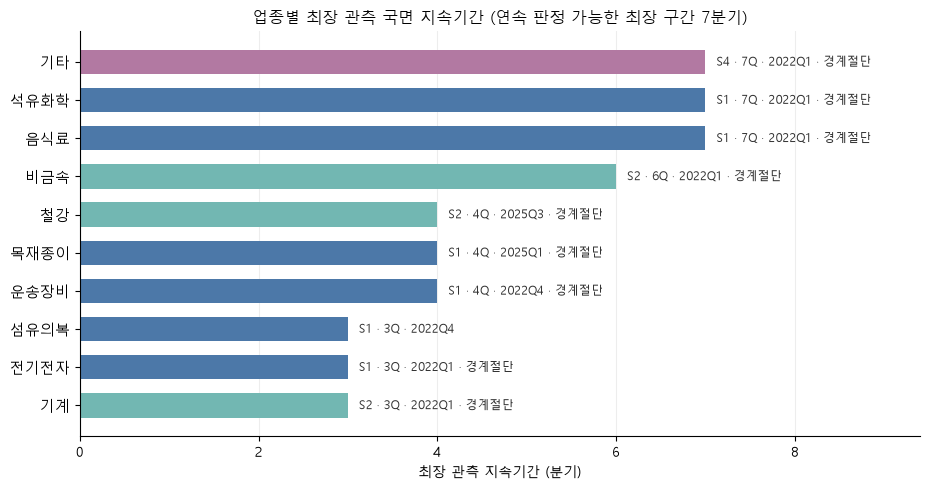

,현재 국면,현재 지속분기,시작분기,좌절단,우절단
industry,,,,,
철강,S2,4.0,2025Q3,False,True
비금속,S2,3.0,2025Q4,False,True
기계,S4,2.0,2026Q1,False,True
운송장비,S2,2.0,2026Q1,False,True
음식료,S2,2.0,2026Q1,False,True
목재종이,S4,2.0,2026Q1,False,True
기타,S1,2.0,2026Q1,False,True
전기전자,S2,1.0,2026Q2,False,True
석유화학,S3,1.0,2026Q2,False,True


,국면,시작분기,지속분기,좌절단,우절단,경계절단
industry,,,,,,
기계,S2,2022Q1,3.0,True,False,True
전기전자,S1,2022Q1,3.0,True,False,True
운송장비,S1,2022Q4,4.0,False,True,True
철강,S2,2025Q3,4.0,False,True,True
음식료,S1,2022Q1,7.0,True,True,True
석유화학,S1,2022Q1,7.0,True,True,True
목재종이,S1,2025Q1,4.0,True,False,True
비금속,S2,2022Q1,6.0,True,False,True
기타,S4,2022Q1,7.0,True,True,True


S1~S4 연속구간 70개 중 2분기 이상 39개(55.7%), 최장 7분기
연속 판정 가능한 블록: [7, 3, 6]; 관측 가능한 최장 지속은 7분기


In [10]:
current = q3_time.current_runs(state, ctx)
runs, longest, share_2plus = q3_time.longest_runs(state, ctx)
valid_block_lengths, max_observable_run = q3_time.valid_blocks(state)

fig = plots.plot_current_runs(current, ctx, main_industries, dirs['fig'])
display(fig)
plt.close(fig)
fig = plots.plot_longest_runs(longest, dirs['fig'], max_observable_run)
display(fig)
plt.close(fig)

display(current[['state', 'run_length', 'state_start_quarter',
                 'run_left_censored', 'run_right_censored']]
        .rename(columns={'state': '현재 국면', 'run_length': '현재 지속분기',
                         'state_start_quarter': '시작분기', 'run_left_censored': '좌절단',
                         'run_right_censored': '우절단'}))
display(longest)
print(f'S1~S4 연속구간 {len(runs)}개 중 2분기 이상 '
      f'{int((runs.run_total_length >= 2).sum())}개({share_2plus:.1f}%), '
      f'최장 {runs.run_total_length.max():.0f}분기')
print(f'연속 판정 가능한 블록: {valid_block_lengths}; 관측 가능한 최장 지속은 {max_observable_run}분기')


## 5.3 관측된 상태 전환

전환은 같은 업종의 실제 인접 분기에서만 계산한다. 전환행렬은 과거 관측 빈도이며 미래 전환확률이 아니다.


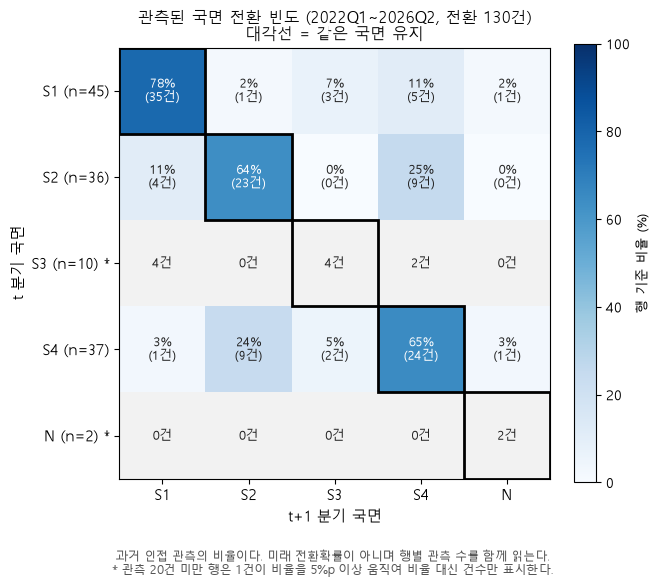

next_state,S1,S2,S3,S4,N
state,,,,,
S1,35,1,3,5,1
S2,4,23,0,9,0
S3,4,0,4,2,0
S4,1,9,2,24,1
N,0,0,0,0,2


next_state,S1,S2,S3,S4,N
state,,,,,
S1,77.8,2.2,6.7,11.1,2.2
S2,11.1,63.9,0.0,25.0,0.0
S3,40.0,0.0,40.0,20.0,0.0
S4,2.7,24.3,5.4,64.9,2.7
N,0.0,0.0,0.0,0.0,100.0


N을 포함한 인접 관측 130건 중 같은 상태 유지 88건(67.7%)
관측 수가 적어 비율 대신 건수 중심으로 읽을 행: S3, N


In [11]:
transitions, transition_counts, transition_pct, transition_row_n, same_state_n = q3_time.transition_matrix(state)
low_sample_rows = q3_time.low_n_rows(transition_row_n)
fig = plots.plot_transition(
    transition_counts, transition_pct, transition_row_n, transitions, ctx, dirs['fig']
)
display(fig)
plt.close(fig)

display(transition_counts)
display(transition_pct.round(1))
q3_result = q3_time.q3_results(
    runs, share_2plus, transitions, same_state_n, current,
    longest=longest, blocks=valid_block_lengths,
    max_observable=max_observable_run, low_rows=low_sample_rows,
)
print(f'N을 포함한 인접 관측 {q3_result["n_adjacent"]}건 중 같은 상태 유지 '
      f'{q3_result["n_same"]}건({q3_result["same_pct"]:.1f}%)')
print(f'관측 수가 적어 비율 대신 건수 중심으로 읽을 행: '
      f'{", ".join(low_sample_rows) if low_sample_rows else "없음"}')


## 6. Q1~Q3 통합 결과

아래 표는 기존 산출물을 업종 단위로 결합한다. `주요 국면`은 유효 관측기간의 최빈 국면, `주요 전환 특성`은 기존 인접 전환 기록에서 가장 자주 관측된 경로다. 동률이면 함께 표시한다. 이는 새로운 판정 지표나 예측이 아니라 기존 Q1~Q3 결과의 요약이다.


In [12]:
def most_frequent_labels(series):
    counts = series.dropna().value_counts()
    if counts.empty:
        return '관측 없음'
    return ', '.join(sorted(counts.index[counts.eq(counts.max())])) + f' ({int(counts.max())}건)'

main_state = state_comp.idxmax(axis=1).rename('주요 국면')
transition_feature = (
    transitions.groupby('industry')['transition_type']
    .apply(most_frequent_labels)
    .rename('주요 전환 특성')
)

integrated_summary = pd.DataFrame(index=ctx.ind_order_emp)
integrated_summary.index.name = '업종'
integrated_summary = integrated_summary.join(main_state)
integrated_summary['최신 국면'] = q1_all['state']
integrated_summary['생산 변화 YoY(%)'] = q1_all['production_yoy']
integrated_summary['고용 변화 YoY(%)'] = q1_all['employment_yoy']
integrated_summary['고용 증감 규모(명)'] = q2['증감인원']
integrated_summary['고용비중(%)'] = q2['고용비중%']
integrated_summary['현재 지속분기'] = current['run_length']
integrated_summary['현재 run 경계절단'] = (
    current['run_left_censored'].fillna(False).astype(bool)
    | current['run_right_censored'].fillna(False).astype(bool)
)
integrated_summary = integrated_summary.join(transition_feature)

display(integrated_summary.round(2))
print(f'표 기준시점: {ctx.latest}; 생산·고용 변화와 증감 규모는 전년동기 {ctx.base_q} 대비')


,주요 국면,최신 국면,생산 변화 YoY(%),고용 변화 YoY(%),고용 증감 규모(명),고용비중(%),현재 지속분기,현재 run 경계절단,주요 전환 특성
업종,,,,,,,,,
기계,S1,S4,-19.55,-6.34,-3979.0,51.19,2.0,True,"S1->S1, S2->S2, S2->S4, S4->S4 (2건)"
전기전자,S1,S2,2.70,-0.41,-116.0,24.37,1.0,True,S1->S1 (5건)
운송장비,S2,S2,19.64,-0.78,-129.0,14.20,2.0,True,"S1->S1, S2->S2 (3건)"
철강,S1,S2,32.65,-1.14,-112.0,8.44,4.0,True,"S2->S2, S4->S4 (3건)"
음식료,S1,S2,0.87,-3.79,-25.0,0.55,2.0,True,S1->S1 (7건)
석유화학,S1,S3,-6.73,9.56,54.0,0.54,1.0,True,S1->S1 (6건)
목재종이,S1,S4,-12.90,-10.08,-48.0,0.37,2.0,True,S1->S1 (5건)
비금속,S2,S2,45.67,-1.08,-2.0,0.16,3.0,True,S2->S2 (7건)
기타,S4,S1,3.03,17.12,25.0,0.15,2.0,True,S4->S4 (6건)


표 기준시점: 2026Q2; 생산·고용 변화와 증감 규모는 전년동기 2025Q2 대비


## 7. 핵심 결과 요약

수치는 위 계산 결과에서 자동으로 가져오며 Markdown에 고정하지 않는다.


In [13]:
dominant_states = main_state.value_counts()
largest_abs_delta = q2['증감인원'].abs().idxmax()
longest_industries = longest.index[longest['지속분기'].eq(longest['지속분기'].max())].tolist()
top_transition = most_frequent_labels(transitions['transition_type'])

display(Markdown(f'''## 데이터가 직접 확인해주는 결과

- 유효 관측기간의 업종별 최빈 국면 분포는 {", ".join(f"{s} {n}개 업종" for s, n in dominant_states.items())}다.
- {ctx.latest} 전년동기 대비 고용 증감 절대규모가 가장 큰 업종은 **{largest_abs_delta}**이며, 증감은 **{q2.loc[largest_abs_delta, "증감인원"]:+,.0f}명**이다.
- 업종별 최장 관측 지속기간의 최댓값은 **{int(longest["지속분기"].max())}분기**이고 해당 업종은 **{", ".join(longest_industries)}**다. 경계절단 여부를 함께 확인해야 한다.
- N을 포함한 인접 관측 {q3_result["n_adjacent"]}건 중 같은 상태 유지는 {q3_result["n_same"]}건({q3_result["same_pct"]:.1f}%)이다.
- 전체 업종에서 가장 자주 관측된 전환 경로는 **{top_transition}**이다.

## 추가 해석이 필요한 내용

- 명목 생산액 변화가 실제 생산량 변화인지, 가격 변화인지
- 고용 증감이 채용·퇴사·기업 이동 중 무엇에서 비롯되었는지
- 특정 국면이나 전환이 나타난 구조적·정책적 원인
- 관측기간 경계나 결측 밖에서 실제 국면이 얼마나 더 지속되었는지

이 노트북은 위 원인과 인과관계를 확정하지 않는다.'''))


## 데이터가 직접 확인해주는 결과

- 유효 관측기간의 업종별 최빈 국면 분포는 S1 6개 업종, S2 3개 업종, S4 1개 업종다.
- 2026Q2 전년동기 대비 고용 증감 절대규모가 가장 큰 업종은 **기계**이며, 증감은 **-3,979명**이다.
- 업종별 최장 관측 지속기간의 최댓값은 **7분기**이고 해당 업종은 **음식료, 석유화학, 기타**다. 경계절단 여부를 함께 확인해야 한다.
- N을 포함한 인접 관측 130건 중 같은 상태 유지는 88건(67.7%)이다.
- 전체 업종에서 가장 자주 관측된 전환 경로는 **S1->S1 (35건)**이다.

## 추가 해석이 필요한 내용

- 명목 생산액 변화가 실제 생산량 변화인지, 가격 변화인지
- 고용 증감이 채용·퇴사·기업 이동 중 무엇에서 비롯되었는지
- 특정 국면이나 전환이 나타난 구조적·정책적 원인
- 관측기간 경계나 결측 밖에서 실제 국면이 얼마나 더 지속되었는지

이 노트북은 위 원인과 인과관계를 확정하지 않는다.

## 실행 및 기존 결과 일치 검증

저장된 검토 완료 `results_summary.json`의 Q1·Q2·Q3 값과 통합본 계산값을 재귀 비교한다. 값, 목록 순서, 문자열이 다르면 셀이 실패한다.


In [14]:
integrated_results = {
    'q1_latest': q1_latest_result,
    'q1_history': q1_history_result,
    'q2': q2_result,
    'q3': q3_result,
}
reference_path = dirs['tab'] / 'results_summary.json'
reference_results = json.loads(reference_path.read_text(encoding='utf-8'))

def assert_equivalent(actual, expected, path='result'):
    if isinstance(expected, dict):
        assert set(actual) == set(expected), f'{path}: 키 불일치'
        for key in expected:
            assert_equivalent(actual[key], expected[key], f'{path}.{key}')
    elif isinstance(expected, list):
        assert len(actual) == len(expected), f'{path}: 목록 길이 불일치'
        for i, (a, e) in enumerate(zip(actual, expected)):
            assert_equivalent(a, e, f'{path}[{i}]')
    elif isinstance(expected, (int, float)) and not isinstance(expected, bool):
        assert np.isclose(actual, expected, rtol=1e-10, atol=1e-10, equal_nan=True), \
            f'{path}: {actual} != {expected}'
    else:
        assert actual == expected, f'{path}: {actual!r} != {expected!r}'

for section, actual in integrated_results.items():
    assert_equivalent(actual, reference_results[section], section)

print('검증 완료: Q1·Q2·Q3 통합 결과가 저장된 검토 완료 결과와 모두 일치합니다.')
print('검증 완료: SettingWithCopyWarning은 오류로 승격했으며 전체 실행 중 발생하지 않았습니다.')


검증 완료: Q1·Q2·Q3 통합 결과가 저장된 검토 완료 결과와 모두 일치합니다.
검증 완료: SettingWithCopyWarning은 오류로 승격했으며 전체 실행 중 발생하지 않았습니다.


## 관찰

상태 분포, 고용 증감 규모, 지속기간과 전환을 각각 분리해 확인한다.

## 해석

핵심 분석은 업종 수준의 관찰 신호이며 기업 원인이나 지원 필요성을 확정하지 않는다.

## 한계

명목 생산액, 분기 자료, 업종 집계 단위의 제약이 있다.

## Takeaway

생산과 고용의 상태·규모·시간 구조를 동일한 180행 패널에서 읽는다.